In [15]:
from google.colab import drive
drive.mount('/content/drive')

import time, json, copy
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def reset_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [17]:
BATCH_SIZE = 8
NUM_WORKERS = 0          # Colab worker issues → 0
LR = 1e-4

NUM_EPOCHS_SCREENING = 15
EARLY_STOP_PATIENCE_SCREENING = None   # مش هنعمل early stop في الـscreening

NUM_EPOCHS_FINAL = 60
EARLY_STOP_PATIENCE_FINAL = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [18]:
DATASET_DIR = Path("/content/drive/MyDrive/Cellula/WaterSegmentation/data")
IMAGES_DIR  = DATASET_DIR / "images"
LABELS_DIR  = DATASET_DIR / "labels"
print("Images:", IMAGES_DIR)
print("Labels:", LABELS_DIR)

Images: /content/drive/MyDrive/Cellula/WaterSegmentation/data/images
Labels: /content/drive/MyDrive/Cellula/WaterSegmentation/data/labels


In [19]:
RAW_BANDS = 12
CHANNEL_NAMES = [
    "Coastal Aerosol", "Blue", "Green", "Red", "NIR", "SWIR1",
    "SWIR2", "QA Band", "MERIT DEM", "Copernicus DEM",
    "ESA WorldCover", "Water Occurrence Probability",
]
GREEN_IDX, NIR_IDX, SWIR1_IDX = 2, 4, 5
CATEGORICAL_CHANNELS = [7, 10]

In [20]:
pairs = []
for image_path in sorted(IMAGES_DIR.glob("*.tif")):
    label_path = LABELS_DIR / f"{image_path.stem}.png"
    if label_path.exists():
        pairs.append((image_path, label_path))
print("Total pairs:", len(pairs))

def has_water(lp):
    with rasterio.open(lp) as s:
        return int(np.any(s.read(1) == 1))

strat = np.array([has_water(l) for _, l in pairs])
print("With water:", int(strat.sum()), "| Without:", int((1-strat).sum()))

train_pairs, temp_pairs, train_labels, temp_labels = train_test_split(
    pairs, strat, test_size=0.30, random_state=SEED, stratify=strat)
val_pairs, test_pairs, _, _ = train_test_split(
    temp_pairs, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels)

print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

Total pairs: 306


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


With water: 261 | Without: 45
Train: 214 | Val: 46 | Test: 46


In [21]:
def add_indices_np(img, feature_names):
    g, n, s = img[GREEN_IDX], img[NIR_IDX], img[SWIR1_IDX]
    eps = 1e-8
    feats = []
    for name in feature_names:
        if name == "NDWI":   feats.append((g - n) / (g + n + eps))
        elif name == "MNDWI": feats.append((g - s) / (g + s + eps))
        elif name == "NDMI":  feats.append((n - s) / (n + s + eps))
        else: raise ValueError(name)
    if feats:
        idx = np.stack(feats, axis=0)
        idx = np.nan_to_num(idx, nan=0., posinf=0., neginf=0.)
        idx = np.clip(idx, -1., 1.)
        return np.concatenate([img, idx], axis=0)
    return img

def add_indices_torch(image, feature_names):
    g, n, s = image[GREEN_IDX], image[NIR_IDX], image[SWIR1_IDX]
    eps = 1e-8
    feats = []
    for name in feature_names:
        if name == "NDWI":   feats.append((g - n) / (g + n + eps))
        elif name == "MNDWI": feats.append((g - s) / (g + s + eps))
        elif name == "NDMI":  feats.append((n - s) / (n + s + eps))
        else: raise ValueError(name)
    if feats:
        idx = torch.stack(feats, dim=0)
        idx = torch.nan_to_num(idx, nan=0., posinf=0., neginf=0.).clamp(-1., 1.)
        image = torch.cat([image, idx], dim=0)
    return image

def compute_channel_stats(pairs, feature_names, norm_channels):
    """TRAIN-ONLY dataset-wise stats."""
    n_ch = len(norm_channels)
    sums, sums_sq, n_px = np.zeros(n_ch), np.zeros(n_ch), 0
    for img_path, _ in pairs:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float64)
        img = add_indices_np(img, feature_names)[norm_channels]
        img = np.nan_to_num(img, nan=0., posinf=0., neginf=0.)
        flat = img.reshape(n_ch, -1)
        sums += flat.sum(axis=1)
        sums_sq += (flat**2).sum(axis=1)
        n_px += flat.shape[1]
    mean = sums / n_px
    var = np.clip(sums_sq / n_px - mean**2, 1e-12, None)
    return mean.astype(np.float32), np.sqrt(var).astype(np.float32)

In [22]:
class WaterSegDataset(Dataset):
    def __init__(self, pairs, mean, std, kept_channels, feature_names, augment=False):
        super().__init__()
        self.pairs = pairs
        self.kept_channels = list(kept_channels)
        self.feature_names = list(feature_names)
        self.augment = augment
        self.mean = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
        self.std  = torch.tensor(std,  dtype=torch.float32).view(-1, 1, 1)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        with rasterio.open(img_path) as src:
            image = torch.from_numpy(src.read().astype(np.float32))   # (12,H,W)
        with rasterio.open(mask_path) as src:
            mask = torch.from_numpy(src.read(1).astype(np.float32))   # (H,W) ← مهم

        image = add_indices_torch(image, self.feature_names)
        image = image[self.kept_channels]

        norm_positions = [i for i, ch in enumerate(self.kept_channels)
                          if ch not in CATEGORICAL_CHANNELS]
        if norm_positions:
            sub = image[norm_positions]
            image = image.clone()
            image[norm_positions] = (sub - self.mean[:len(norm_positions)]) / \
                                     self.std[:len(norm_positions)]

        if self.augment:
            do_h = torch.rand(1).item() > 0.5
            do_v = torch.rand(1).item() > 0.5
            do_r = torch.rand(1).item() > 0.5
            if do_h:
                image = torch.flip(image, dims=[2]).clone()
                mask  = torch.flip(mask,  dims=[1]).clone()
            if do_v:
                image = torch.flip(image, dims=[1]).clone()
                mask  = torch.flip(mask,  dims=[0]).clone()
            if do_r:
                image = torch.rot90(image, k=1, dims=[1, 2]).clone()
                mask  = torch.rot90(mask,  k=1, dims=[0, 1]).clone()
            if norm_positions and torch.rand(1).item() > 0.5:
                noise = torch.randn_like(image[norm_positions]) * 0.05
                image[norm_positions] += noise

        mask = mask.unsqueeze(0)   # (1,H,W)
        return image, mask

In [23]:
class UNet(nn.Module):
    """
    Standard U-Net with proper channel tracking.
    Encoder channels double per level. Decoder input = upconv_out + skip.
    Works for any (in_ch, depth, base_f).
    """
    def __init__(self, in_ch=15, out_ch=1, base_f=16, depth=5):
        super().__init__()
        def conv_block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.Conv2d(oc, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            )

        # Encoder channels: base_f, 2*base_f, 4*base_f, ...
        enc_ch = [base_f * (2 ** i) for i in range(depth)]

        self.encoders = nn.ModuleList()
        c_in = in_ch
        for oc in enc_ch:
            self.encoders.append(conv_block(c_in, oc))
            c_in = oc

        # Bottleneck
        bn_ch = enc_ch[-1] * 2
        self.bottleneck = conv_block(c_in, bn_ch)

        # Decoder
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        f = bn_ch
        for skip_ch in reversed(enc_ch):
            up_ch = f // 2
            self.upconvs.append(nn.ConvTranspose2d(f, up_ch, kernel_size=2, stride=2))
            self.decoders.append(conv_block(up_ch + skip_ch, up_ch))
            f = up_ch

        self.final = nn.Conv2d(f, out_ch, kernel_size=1)
        self.pool  = nn.MaxPool2d(2)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        return self.final(x)

# Sanity check
with torch.no_grad():
    m = UNet(in_ch=13, out_ch=1, base_f=16, depth=5).to(DEVICE)
    y = m(torch.randn(2, 13, 128, 128).to(DEVICE))
    print("Sanity check output:", y.shape)   # لازم (2,1,128,128)
    del m, y

Sanity check output: torch.Size([2, 1, 128, 128])


In [24]:
def compute_metrics(logits, targets, thr=0.5):
    preds = (torch.sigmoid(logits) > thr).float()
    tp = ((preds==1)&(targets==1)).sum().item()
    fp = ((preds==1)&(targets==0)).sum().item()
    fn = ((preds==0)&(targets==1)).sum().item()
    tn = ((preds==0)&(targets==0)).sum().item()
    eps = 1e-8
    p = tp/(tp+fp+eps); r = tp/(tp+fn+eps)
    return {"iou": tp/(tp+fp+fn+eps),
            "precision": p, "recall": r,
            "f1": 2*p*r/(p+r+eps),
            "accuracy": (tp+tn)/(tp+tn+fp+fn+eps)}

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        inter = (p*t).sum()
        return 1.0 - (2*inter + self.smooth)/(p.sum()+t.sum()+self.smooth)

def compute_pos_weight(pairs):
    tw = tb = 0
    for _, lbl in pairs:
        with rasterio.open(lbl) as s:
            m = s.read(1)
            tw += int((m==1).sum()); tb += int((m==0).sum())
    return tb / max(tw, 1)

POS_WEIGHT = compute_pos_weight(train_pairs)
print(f"pos_weight (train): {POS_WEIGHT:.4f}")

def make_loss(pos_weight_val):
    pw = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)
    bce = nn.BCEWithLogitsLoss(pos_weight=pw)
    dice = DiceLoss()
    def loss_fn(logits, targets):
        return bce(logits, targets) + dice(logits, targets)
    return loss_fn

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


pos_weight (train): 2.6505


In [25]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    tot, L, T = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot += loss.item() * x.size(0)
        L.append(logits.detach().cpu()); T.append(y.detach().cpu())
    return tot/len(loader.dataset), compute_metrics(torch.cat(L), torch.cat(T))

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    tot, L, T = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x); loss = loss_fn(logits, y)
        tot += loss.item() * x.size(0)
        L.append(logits.cpu()); T.append(y.cpu())
    return tot/len(loader.dataset), compute_metrics(torch.cat(L), torch.cat(T))


def run_experiment(exp_name, kept_channels, feature_names, config_description,
                   num_epochs=NUM_EPOCHS_SCREENING,
                   patience=EARLY_STOP_PATIENCE_SCREENING,
                   save_dir=None, verbose=True):
    reset_seed(SEED)   # ← مهم لكل تجربة

    num_channels = len(kept_channels)
    norm_ch = [c for c in kept_channels if c not in CATEGORICAL_CHANNELS]
    mean, std = compute_channel_stats(train_pairs, feature_names, norm_ch)

    train_ds = WaterSegDataset(train_pairs, mean, std, kept_channels, feature_names, True)
    val_ds   = WaterSegDataset(val_pairs,   mean, std, kept_channels, feature_names, False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    model = UNet(in_ch=num_channels, out_ch=1, base_f=16, depth=5).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = make_loss(POS_WEIGHT)

    best_val_iou = -float("inf")    # ← مش 0.0
    best_epoch, best_metrics, best_state = 0, {}, None
    no_improve, history = 0, []
    t0 = time.time()

    for epoch in range(1, num_epochs+1):
        tr_loss, tr_m = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
        vl_loss, vl_m = evaluate(model, val_loader, loss_fn, DEVICE)
        history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": vl_loss,
                        **{f"val_{k}": v for k, v in vl_m.items()}})
        if verbose:
            print(f"[{exp_name}] Ep {epoch:02d} | TrL {tr_loss:.4f} | VL {vl_loss:.4f} | "
                  f"IoU {vl_m['iou']:.4f} | F1 {vl_m['f1']:.4f} | "
                  f"P {vl_m['precision']:.4f} | R {vl_m['recall']:.4f}")

        if vl_m["iou"] > best_val_iou:
            best_val_iou = vl_m["iou"]
            best_epoch = epoch
            best_metrics = vl_m.copy()
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if patience is not None and no_improve >= patience:
                if verbose: print(f"[{exp_name}] Early stop at ep {epoch}")
                break

    train_time = time.time() - t0
    ckpt = None
    if save_dir is not None and best_state is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        ckpt = save_dir / f"best_{exp_name}.pt"
        torch.save(best_state, ckpt)

    return {"experiment": exp_name, "config_description": config_description,
            "kept_channels": list(kept_channels),
            "features": "+".join(feature_names) if feature_names else "None",
            "input_channels": num_channels,
            "best_val_iou": best_val_iou,
            "val_f1": best_metrics.get("f1", np.nan),
            "val_precision": best_metrics.get("precision", np.nan),
            "val_recall": best_metrics.get("recall", np.nan),
            "best_epoch": best_epoch, "train_time_sec": train_time,
            "checkpoint": str(ckpt) if ckpt else None,
            "history": history}

In [26]:
ALL_FEATURES = ["NDWI", "MNDWI", "NDMI"]

def make_kept_channels(feature_list, remove=()):
    """kept indices in (12 + len(feature_list)) space, matching add_indices order."""
    kept = list(range(RAW_BANDS))
    kept += [RAW_BANDS + i for i in range(len(feature_list))]
    return [c for c in kept if c not in set(remove)]

# تأكد الأرقام سليمة
for name in ["NDWI", "MNDWI", "NDMI"]:
    k = make_kept_channels([name])
    print(f"{name}: {k}  max={max(k)}")   # لازم max = 12

# ------- SANITY CHECK: 14ch NDWI + MNDWI -------
sanity = run_experiment(
    exp_name="SANITY_14ch_NDWI_MNDWI",
    kept_channels=make_kept_channels(["NDWI", "MNDWI"]),
    feature_names=["NDWI", "MNDWI"],
    config_description="Sanity: 12 raw + NDWI + MNDWI (14ch)",
)
sanity.pop("history", None)
print("\n>>> Sanity Val IoU:", sanity["best_val_iou"])

NDWI: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  max=12
MNDWI: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  max=12
NDMI: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  max=12
[SANITY_14ch_NDWI_MNDWI] Ep 01 | TrL 1.6641 | VL 1.5613 | IoU 0.3049 | F1 0.4673 | P 0.3262 | R 0.8236
[SANITY_14ch_NDWI_MNDWI] Ep 02 | TrL 1.3911 | VL 1.2629 | IoU 0.4037 | F1 0.5752 | P 0.4712 | R 0.7383
[SANITY_14ch_NDWI_MNDWI] Ep 03 | TrL 1.2167 | VL 1.1999 | IoU 0.4861 | F1 0.6542 | P 0.6441 | R 0.6646
[SANITY_14ch_NDWI_MNDWI] Ep 04 | TrL 1.1349 | VL 1.1596 | IoU 0.5008 | F1 0.6673 | P 0.5471 | R 0.8554
[SANITY_14ch_NDWI_MNDWI] Ep 05 | TrL 1.1372 | VL 1.1392 | IoU 0.5720 | F1 0.7277 | P 0.7581 | R 0.6997
[SANITY_14ch_NDWI_MNDWI] Ep 06 | TrL 1.0870 | VL 1.0467 | IoU 0.5857 | F1 0.7387 | P 0.6887 | R 0.7966
[SANITY_14ch_NDWI_MNDWI] Ep 07 | TrL 1.0411 | VL 1.1534 | IoU 0.4227 | F1 0.5942 | P 0.4645 | R 0.8244
[SANITY_14ch_NDWI_MNDWI] Ep 08 | TrL 1.0194 | VL 1.0175 | IoU 0.5640 | F1 0.7212 | P 0.6230 | R 0.8561
[SAN

In [27]:
stage1_exps = [
    dict(name="E0_raw12",                feats=[],                 desc="12 raw"),
    dict(name="E1_raw12_NDWI",           feats=["NDWI"],           desc="12 raw + NDWI (13ch)"),
    dict(name="E2_raw12_MNDWI",          feats=["MNDWI"],          desc="12 raw + MNDWI (13ch)"),
    dict(name="E3_raw12_NDWI_MNDWI",     feats=["NDWI", "MNDWI"],  desc="12 raw + NDWI + MNDWI (14ch)"),
]

stage1_results = []
for e in stage1_exps:
    res = run_experiment(e["name"], make_kept_channels(e["feats"]),
                         e["feats"], e["desc"])
    res.pop("history", None)
    stage1_results.append(res)

df_stage1 = pd.DataFrame(stage1_results).sort_values("best_val_iou", ascending=False)
df_stage1

[E0_raw12] Ep 01 | TrL 1.5909 | VL 1.5027 | IoU 0.3543 | F1 0.5232 | P 0.4577 | R 0.6105
[E0_raw12] Ep 02 | TrL 1.4224 | VL 1.3149 | IoU 0.3928 | F1 0.5641 | P 0.4634 | R 0.7207
[E0_raw12] Ep 03 | TrL 1.2903 | VL 1.2526 | IoU 0.4652 | F1 0.6350 | P 0.6098 | R 0.6624
[E0_raw12] Ep 04 | TrL 1.2474 | VL 1.2139 | IoU 0.4909 | F1 0.6586 | P 0.6248 | R 0.6962
[E0_raw12] Ep 05 | TrL 1.2211 | VL 1.2333 | IoU 0.4484 | F1 0.6192 | P 0.5397 | R 0.7262
[E0_raw12] Ep 06 | TrL 1.1643 | VL 1.2059 | IoU 0.4397 | F1 0.6108 | P 0.5359 | R 0.7101
[E0_raw12] Ep 07 | TrL 1.1500 | VL 1.1690 | IoU 0.5426 | F1 0.7035 | P 0.7348 | R 0.6747
[E0_raw12] Ep 08 | TrL 1.1396 | VL 1.1535 | IoU 0.4935 | F1 0.6608 | P 0.5846 | R 0.7599
[E0_raw12] Ep 09 | TrL 1.0851 | VL 1.1423 | IoU 0.5523 | F1 0.7116 | P 0.7278 | R 0.6961
[E0_raw12] Ep 10 | TrL 1.0972 | VL 1.1153 | IoU 0.5497 | F1 0.7094 | P 0.7086 | R 0.7102
[E0_raw12] Ep 11 | TrL 1.0463 | VL 1.0765 | IoU 0.5911 | F1 0.7430 | P 0.7414 | R 0.7446
[E0_raw12] Ep 12 | Tr

,experiment,config_description,kept_channels,features,input_channels,best_val_iou,val_f1,val_precision,val_recall,best_epoch,train_time_sec,checkpoint
1,E1_raw12_NDWI,12 raw + NDWI (13ch),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",NDWI,13,0.604301,0.753351,0.731554,0.776487,14,112.335685,None
0,E0_raw12,12 raw,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",None,12,0.603541,0.752760,0.826024,0.691433,15,110.135927,None
2,E2_raw12_MNDWI,12 raw + MNDWI (13ch),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",MNDWI,13,0.601885,0.751471,0.809806,0.700976,10,113.243539,None
3,E3_raw12_NDWI_MNDWI,12 raw + NDWI + MNDWI (14ch),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",NDWI+MNDWI,14,0.600963,0.750752,0.744933,0.756662,10,114.602741,None


In [28]:
BASE_FEATS = ["NDWI", "MNDWI"]
BASE_KEPT  = make_kept_channels(BASE_FEATS)

ABLATION_TARGETS = {
    "QA Band": 7, "MERIT DEM": 8, "Copernicus DEM": 9,
    "ESA WorldCover": 10, "Water Occ": 11,
}

ablation_results = []
for name, ch in ABLATION_TARGETS.items():
    kept = [c for c in BASE_KEPT if c != ch]
    res = run_experiment(f"ABL_no_{name.replace(' ','_')}", kept, BASE_FEATS,
                         f"14ch − {name} ({len(kept)}ch)")
    res.pop("history", None); res["removed_channel"] = name
    ablation_results.append(res)

# baseline 14ch same code path
base_res = run_experiment("ABL_base_14ch", BASE_KEPT, BASE_FEATS,
                          "12 raw + NDWI + MNDWI (14ch)")
base_res.pop("history", None); base_res["removed_channel"] = "—"
ablation_results.append(base_res)

df_ablation = pd.DataFrame(ablation_results).sort_values("best_val_iou", ascending=False)
df_ablation

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


[ABL_no_QA_Band] Ep 01 | TrL 1.4523 | VL 1.3944 | IoU 0.3571 | F1 0.5262 | P 0.3762 | R 0.8753
[ABL_no_QA_Band] Ep 02 | TrL 1.2298 | VL 1.1633 | IoU 0.5432 | F1 0.7040 | P 0.6851 | R 0.7240
[ABL_no_QA_Band] Ep 03 | TrL 1.1042 | VL 1.0565 | IoU 0.5150 | F1 0.6799 | P 0.5572 | R 0.8717
[ABL_no_QA_Band] Ep 04 | TrL 1.0455 | VL 1.0175 | IoU 0.5671 | F1 0.7238 | P 0.6278 | R 0.8543
[ABL_no_QA_Band] Ep 05 | TrL 1.0253 | VL 1.1363 | IoU 0.4234 | F1 0.5949 | P 0.4280 | R 0.9752
[ABL_no_QA_Band] Ep 06 | TrL 0.9907 | VL 0.9842 | IoU 0.5919 | F1 0.7436 | P 0.6883 | R 0.8086
[ABL_no_QA_Band] Ep 07 | TrL 0.9515 | VL 1.0074 | IoU 0.5175 | F1 0.6821 | P 0.5375 | R 0.9329
[ABL_no_QA_Band] Ep 08 | TrL 0.9682 | VL 0.9811 | IoU 0.5234 | F1 0.6871 | P 0.5522 | R 0.9093
[ABL_no_QA_Band] Ep 09 | TrL 0.9550 | VL 1.0118 | IoU 0.5109 | F1 0.6763 | P 0.5300 | R 0.9339
[ABL_no_QA_Band] Ep 10 | TrL 0.9518 | VL 0.9583 | IoU 0.5276 | F1 0.6908 | P 0.5547 | R 0.9152
[ABL_no_QA_Band] Ep 11 | TrL 0.9145 | VL 0.9549 | 

,experiment,config_description,kept_channels,features,input_channels,best_val_iou,val_f1,val_precision,val_recall,best_epoch,train_time_sec,checkpoint,removed_channel
3,ABL_no_ESA_WorldCover,14ch − ESA WorldCover (13ch),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13]",NDWI+MNDWI,13,0.623816,0.768334,0.791196,0.746755,9,112.182783,None,ESA WorldCover
4,ABL_no_Water_Occ,14ch − Water Occ (13ch),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13]",NDWI+MNDWI,13,0.613171,0.760206,0.806833,0.718673,10,111.330041,None,Water Occ
0,ABL_no_QA_Band,14ch − QA Band (13ch),"[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13]",NDWI+MNDWI,13,0.608135,0.756324,0.692669,0.832862,12,111.811677,None,QA Band
1,ABL_no_MERIT_DEM,14ch − MERIT DEM (13ch),"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13]",NDWI+MNDWI,13,0.605977,0.754652,0.792775,0.720027,10,110.817205,None,MERIT DEM
2,ABL_no_Copernicus_DEM,14ch − Copernicus DEM (13ch),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13]",NDWI+MNDWI,13,0.605014,0.753905,0.795620,0.716346,10,110.643743,None,Copernicus DEM
5,ABL_base_14ch,12 raw + NDWI + MNDWI (14ch),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",NDWI+MNDWI,14,0.600963,0.750752,0.744933,0.756662,10,112.493633,None,—


In [29]:
all_so_far = pd.concat([df_stage1, df_ablation], ignore_index=True)\
               .sort_values("best_val_iou", ascending=False)\
               .reset_index(drop=True)

best_row = all_so_far.iloc[0]
current_kept  = list(best_row["kept_channels"])
current_feats = best_row["features"].split("+") if best_row["features"] != "None" else []

print("Greedy start:", current_feats, f"({len(current_kept)}ch) IoU={best_row['best_val_iou']:.4f}")

TOLERANCE = 0.001     # قبول فقط لو IoU ≥ best - 0.001
MAX_ROUNDS = 3
greedy_log = []

for r in range(1, MAX_ROUNDS+1):
    improved = False
    for ch in [c for c in current_kept if c < RAW_BANDS]:
        trial = [c for c in current_kept if c != ch]
        res = run_experiment(f"GREEDY_r{r}_drop_ch{ch}", trial, current_feats,
                             f"Drop ch{ch} ({len(trial)}ch)")
        res.pop("history", None); greedy_log.append(res)
        delta = res["best_val_iou"] - best_row["best_val_iou"]
        if delta >= -TOLERANCE:
            print(f"  drop ch{ch}: ΔIoU={delta:+.4f} → ACCEPT")
            current_kept = trial; best_row = res; improved = True
        else:
            print(f"  drop ch{ch}: ΔIoU={delta:+.4f} → reject")
    if not improved:
        print(f"Stop at round {r}.")
        break

df_greedy = pd.DataFrame(greedy_log) if greedy_log else pd.DataFrame()
print("Final:", current_feats, f"({len(current_kept)}ch) IoU={best_row['best_val_iou']:.4f}")

Greedy start: ['NDWI', 'MNDWI'] (13ch) IoU=0.6238


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


[GREEDY_r1_drop_ch0] Ep 01 | TrL 1.5713 | VL 1.5891 | IoU 0.3326 | F1 0.4992 | P 0.3888 | R 0.6974
[GREEDY_r1_drop_ch0] Ep 02 | TrL 1.4261 | VL 1.3946 | IoU 0.3762 | F1 0.5467 | P 0.4390 | R 0.7244
[GREEDY_r1_drop_ch0] Ep 03 | TrL 1.3276 | VL 1.2806 | IoU 0.5226 | F1 0.6865 | P 0.7200 | R 0.6559
[GREEDY_r1_drop_ch0] Ep 04 | TrL 1.2016 | VL 1.1662 | IoU 0.5006 | F1 0.6672 | P 0.5933 | R 0.7623
[GREEDY_r1_drop_ch0] Ep 05 | TrL 1.1455 | VL 1.1471 | IoU 0.6044 | F1 0.7534 | P 0.7900 | R 0.7200
[GREEDY_r1_drop_ch0] Ep 06 | TrL 1.1133 | VL 1.0888 | IoU 0.5918 | F1 0.7436 | P 0.7029 | R 0.7893
[GREEDY_r1_drop_ch0] Ep 07 | TrL 1.0985 | VL 1.0993 | IoU 0.6237 | F1 0.7683 | P 0.8311 | R 0.7143
[GREEDY_r1_drop_ch0] Ep 08 | TrL 1.0946 | VL 1.0721 | IoU 0.5554 | F1 0.7141 | P 0.6419 | R 0.8047
[GREEDY_r1_drop_ch0] Ep 09 | TrL 1.0689 | VL 1.0711 | IoU 0.5735 | F1 0.7289 | P 0.6690 | R 0.8007
[GREEDY_r1_drop_ch0] Ep 10 | TrL 1.0790 | VL 1.0409 | IoU 0.6206 | F1 0.7659 | P 0.7683 | R 0.7635
[GREEDY_r1

In [30]:
dfs = [df_stage1, df_ablation] + ([df_greedy] if not df_greedy.empty else [])
all_results = pd.concat(dfs, ignore_index=True)\
                .sort_values(["best_val_iou","val_f1"], ascending=False)\
                .reset_index(drop=True)

cols = ["experiment","config_description","input_channels",
        "best_val_iou","val_f1","val_precision","val_recall",
        "best_epoch","train_time_sec"]

print("="*100)
print("ALL CONFIGURATIONS (by Val IoU)")
print("="*100)
display(all_results[cols])
all_results[cols].to_csv(DATASET_DIR/"channel_optimization_results.csv", index=False)

best_overall = all_results.iloc[0]
THRESH = best_overall["best_val_iou"] - 0.005
comp = all_results[all_results["best_val_iou"] >= THRESH]
smallest = comp.sort_values(["input_channels","best_val_iou"],
                            ascending=[True, False]).iloc[0]

print("\nBEST OVERALL:")
print(best_overall[cols].to_dict())
print("\nSMALLEST COMPETITIVE (within 0.005 IoU):")
print(smallest[cols].to_dict())

ALL CONFIGURATIONS (by Val IoU)


,experiment,config_description,input_channels,best_val_iou,val_f1,val_precision,val_recall,best_epoch,train_time_sec
0,GREEDY_r1_drop_ch0,Drop ch0 (12ch),12,0.630493,0.773377,0.788388,0.758927,11,109.366491
1,ABL_no_ESA_WorldCover,14ch − ESA WorldCover (13ch),13,0.623816,0.768334,0.791196,0.746755,9,112.182783
2,ABL_no_Water_Occ,14ch − Water Occ (13ch),13,0.613171,0.760206,0.806833,0.718673,10,111.330041
3,ABL_no_QA_Band,14ch − QA Band (13ch),13,0.608135,0.756324,0.692669,0.832862,12,111.811677
4,ABL_no_MERIT_DEM,14ch − MERIT DEM (13ch),13,0.605977,0.754652,0.792775,0.720027,10,110.817205
5,ABL_no_Copernicus_DEM,14ch − Copernicus DEM (13ch),13,0.605014,0.753905,0.795620,0.716346,10,110.643743
6,E1_raw12_NDWI,12 raw + NDWI (13ch),13,0.604301,0.753351,0.731554,0.776487,14,112.335685
7,E0_raw12,12 raw,12,0.603541,0.752760,0.826024,0.691433,15,110.135927
8,E2_raw12_MNDWI,12 raw + MNDWI (13ch),13,0.601885,0.751471,0.809806,0.700976,10,113.243539
9,E3_raw12_NDWI_MNDWI,12 raw + NDWI + MNDWI (14ch),14,0.600963,0.750752,0.744933,0.756662,10,114.602741



BEST OVERALL:
{'experiment': 'GREEDY_r1_drop_ch0', 'config_description': 'Drop ch0 (12ch)', 'input_channels': 12, 'best_val_iou': 0.6304926418099951, 'val_f1': 0.7733768574819434, 'val_precision': 0.7883878747753246, 'val_recall': 0.7589267931828743, 'best_epoch': 11, 'train_time_sec': 109.36649060249329}

SMALLEST COMPETITIVE (within 0.005 IoU):
{'experiment': 'GREEDY_r1_drop_ch0', 'config_description': 'Drop ch0 (12ch)', 'input_channels': 12, 'best_val_iou': 0.6304926418099951, 'val_f1': 0.7733768574819434, 'val_precision': 0.7883878747753246, 'val_recall': 0.7589267931828743, 'best_epoch': 11, 'train_time_sec': 109.36649060249329}


In [31]:
FINAL = best_overall   # أو smallest لو عايز أصغر
final_kept  = list(FINAL["kept_channels"])
final_feats = FINAL["features"].split("+") if FINAL["features"] != "None" else []

print("FINAL:", final_feats, f"({len(final_kept)}ch)  screen IoU={FINAL['best_val_iou']:.4f}")

FINAL_DIR = DATASET_DIR / "final_model"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

final_result = run_experiment(
    exp_name="FINAL",
    kept_channels=final_kept,
    feature_names=final_feats,
    config_description="Final selected",
    num_epochs=NUM_EPOCHS_FINAL,
    patience=EARLY_STOP_PATIENCE_FINAL,
    save_dir=FINAL_DIR,
)
final_result.pop("history", None)
display(pd.Series(final_result, name="Final Result"))

FINAL: ['NDWI', 'MNDWI'] (12ch)  screen IoU=0.6305


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


[FINAL] Ep 01 | TrL 1.5713 | VL 1.5891 | IoU 0.3326 | F1 0.4992 | P 0.3888 | R 0.6974
[FINAL] Ep 02 | TrL 1.4261 | VL 1.3946 | IoU 0.3762 | F1 0.5467 | P 0.4390 | R 0.7244
[FINAL] Ep 03 | TrL 1.3276 | VL 1.2806 | IoU 0.5226 | F1 0.6865 | P 0.7200 | R 0.6559
[FINAL] Ep 04 | TrL 1.2016 | VL 1.1662 | IoU 0.5006 | F1 0.6672 | P 0.5933 | R 0.7623
[FINAL] Ep 05 | TrL 1.1455 | VL 1.1471 | IoU 0.6044 | F1 0.7534 | P 0.7900 | R 0.7200
[FINAL] Ep 06 | TrL 1.1133 | VL 1.0888 | IoU 0.5918 | F1 0.7436 | P 0.7029 | R 0.7893
[FINAL] Ep 07 | TrL 1.0985 | VL 1.0993 | IoU 0.6237 | F1 0.7683 | P 0.8311 | R 0.7143
[FINAL] Ep 08 | TrL 1.0946 | VL 1.0721 | IoU 0.5554 | F1 0.7141 | P 0.6419 | R 0.8047
[FINAL] Ep 09 | TrL 1.0689 | VL 1.0711 | IoU 0.5735 | F1 0.7289 | P 0.6690 | R 0.8007
[FINAL] Ep 10 | TrL 1.0790 | VL 1.0409 | IoU 0.6206 | F1 0.7659 | P 0.7683 | R 0.7635
[FINAL] Ep 11 | TrL 1.0313 | VL 1.0326 | IoU 0.6305 | F1 0.7734 | P 0.7884 | R 0.7589
[FINAL] Ep 12 | TrL 1.0116 | VL 1.0706 | IoU 0.5427 | 

,Final Result
experiment,FINAL
config_description,Final selected
kept_channels,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13]"
features,NDWI+MNDWI
input_channels,12
best_val_iou,0.645256
val_f1,0.784384
val_precision,0.807471
val_recall,0.76258
best_epoch,40


In [32]:
norm_ch = [c for c in final_kept if c not in CATEGORICAL_CHANNELS]
mean, std = compute_channel_stats(train_pairs, final_feats, norm_ch)

with open(FINAL_DIR/"final_channel_stats.json", "w") as f:
    json.dump({"features": final_feats, "kept_channels": final_kept,
               "mean": mean.tolist(), "std": std.tolist()}, f, indent=4)

test_ds = WaterSegDataset(test_pairs, mean, std, final_kept, final_feats, augment=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

model = UNet(in_ch=len(final_kept), out_ch=1, base_f=16, depth=5).to(DEVICE)
model.load_state_dict(torch.load(final_result["checkpoint"], map_location=DEVICE))
model.eval()

loss_fn = make_loss(POS_WEIGHT)
test_loss, test_m = evaluate(model, test_loader, loss_fn, DEVICE)

print("="*60)
print("FINAL TEST (test set used ONCE)")
print("="*60)
print(f"Loss      : {test_loss:.4f}")
print(f"IoU       : {test_m['iou']:.4f}")
print(f"F1        : {test_m['f1']:.4f}")
print(f"Precision : {test_m['precision']:.4f}")
print(f"Recall    : {test_m['recall']:.4f}")
print(f"Accuracy  : {test_m['accuracy']:.4f}")

FINAL TEST (test set used ONCE)
Loss      : 0.8851
IoU       : 0.6505
F1        : 0.7882
Precision : 0.8498
Recall    : 0.7350
Accuracy  : 0.9130


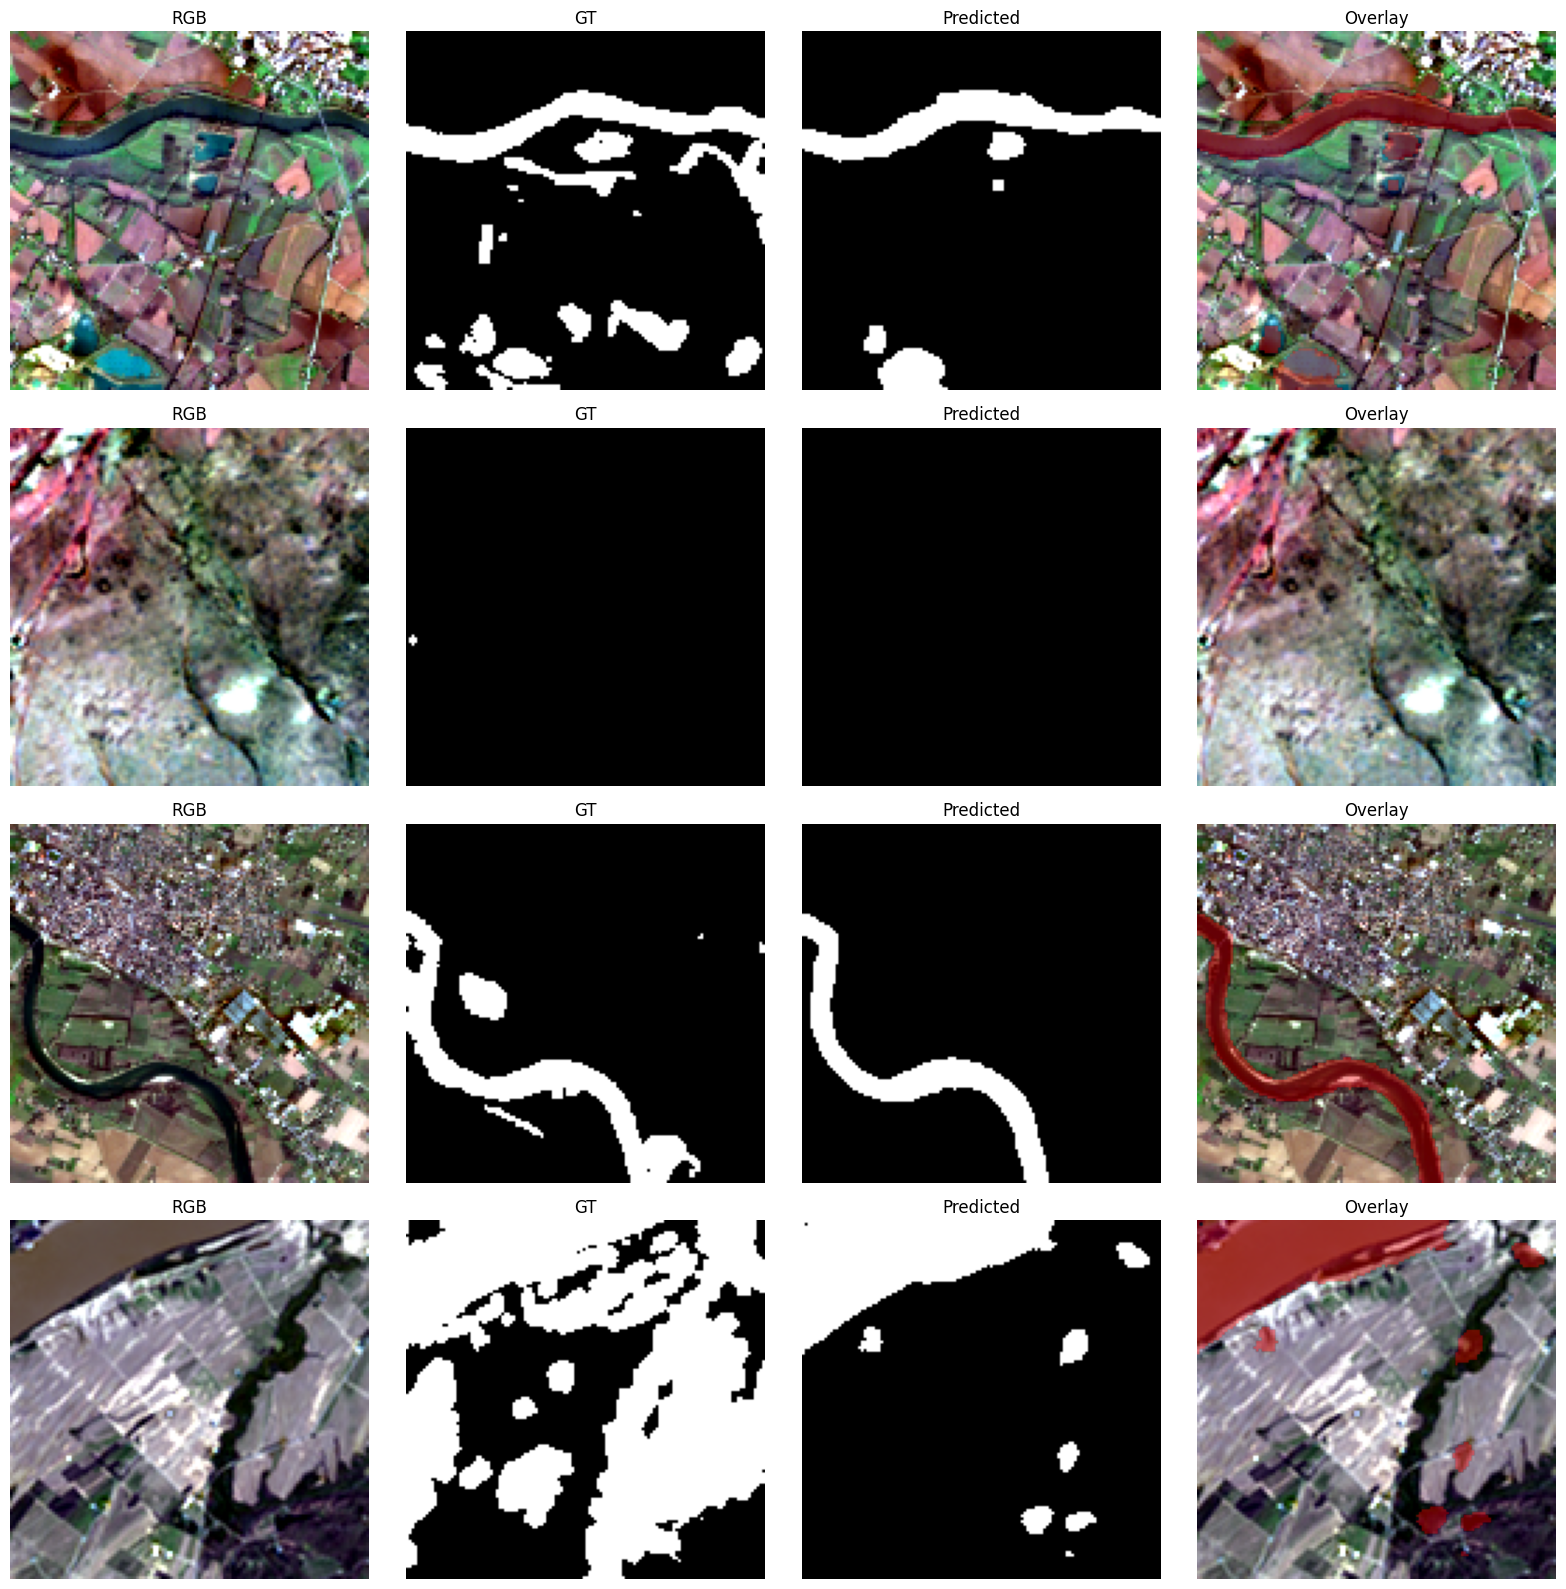

In [35]:
@torch.no_grad()
def predict(model, x):
    logits = model(x.unsqueeze(0).to(DEVICE))
    return (torch.sigmoid(logits) > 0.5).squeeze().cpu().numpy()

def visualize(n=4):
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    if n == 1: axes = axes[None, :]
    for i in range(n):
        img_path, _ = test_pairs[i]
        with rasterio.open(img_path) as s:
            raw = s.read()
        x, y = test_ds[i]
        rgb = np.stack([raw[3], raw[2], raw[1]], axis=-1).astype(np.float32)
        for c in range(3):
            lo, hi = np.percentile(rgb[..., c], (2, 98))
            rgb[..., c] = np.clip((rgb[..., c]-lo)/(hi-lo+1e-8), 0, 1)
        pred = predict(model, x); gt = y.squeeze().numpy()
        axes[i,0].imshow(rgb);                 axes[i,0].set_title("RGB")
        axes[i,1].imshow(gt, cmap="gray");     axes[i,1].set_title("GT")
        axes[i,2].imshow(pred, cmap="gray");   axes[i,2].set_title("Predicted")
        axes[i,3].imshow(rgb)
        axes[i,3].imshow(np.ma.masked_where(pred==0, pred), cmap="autumn", alpha=0.4)
        axes[i,3].set_title("Overlay")
        for j in range(4): axes[i,j].axis("off")
    plt.tight_layout(); plt.show()

visualize(4)

In [34]:
baseline = all_results[all_results["experiment"] == "E0_raw12"].iloc[0]
removed_idx = sorted(set(range(RAW_BANDS)) - set(c for c in final_kept if c < RAW_BANDS))
removed_names = [CHANNEL_NAMES[c] for c in removed_idx]

print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"Baseline channels         : {baseline['input_channels']} (12 raw)")
print(f"Final channels            : {len(final_kept)}")
print(f"Removed raw channels      : {removed_names if removed_names else 'None'}")
print(f"Added features            : {final_feats}")
print(f"Baseline Val IoU          : {baseline['best_val_iou']:.4f}")
print(f"Final Val IoU             : {FINAL['best_val_iou']:.4f}")
print(f"Final Test IoU            : {test_m['iou']:.4f}")
print(f"Final Test F1             : {test_m['f1']:.4f}")
print(f"Final Test Precision      : {test_m['precision']:.4f}")
print(f"Final Test Recall         : {test_m['recall']:.4f}")
print()
print("Selected because: highest Validation IoU with competitive F1 "
      "and no unnecessary channels, using ablation + greedy search.")

FINAL SUMMARY
Baseline channels         : 12 (12 raw)
Final channels            : 12
Removed raw channels      : ['Coastal Aerosol', 'ESA WorldCover']
Added features            : ['NDWI', 'MNDWI']
Baseline Val IoU          : 0.6035
Final Val IoU             : 0.6305
Final Test IoU            : 0.6505
Final Test F1             : 0.7882
Final Test Precision      : 0.8498
Final Test Recall         : 0.7350

Selected because: highest Validation IoU with competitive F1 and no unnecessary channels, using ablation + greedy search.
